# Exploratory Data Analysis — Isolate-only nodes & edges

- Files: `analysis_output/nodes_isolate_only.tsv` and `analysis_output/edges_isolate_only.tsv`.
- Dataset: nodes detected in at least one isolate and absent from the marine broth blank.
- Approach: data quality → network structure → annotation coverage → biology.
- Each section checks whether the data are trustworthy for the next step.
- Note: `RTMean` is in seconds in GNPS2 - converted it to minutes on load.

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.facecolor"] = "white"

OUT_DIR = Path("results/msms_analysis_output")   # run this notebook from the repo root

nodes = pd.read_csv(OUT_DIR / "nodes_isolate_only.tsv", sep="\t", low_memory=False)
edges = pd.read_csv(OUT_DIR / "edges_isolate_only.tsv", sep="\t")

nodes["RTMean_min"] = nodes["RTMean"] / 60

ISOLATE_COLS = [c for c in nodes.columns
                 if c.startswith("ATTRIBUTE_ORGANISM:GNPSGROUP:") and c != "ATTRIBUTE_ORGANISM:GNPSGROUP:nan"]
ISOLATE_LABELS = [c.split(":")[-1] for c in ISOLATE_COLS]

print(f"Nodes: {nodes.shape[0]} rows x {nodes.shape[1]} columns")
print(f"Edges: {edges.shape[0]} rows x {edges.shape[1]} columns")
print(f"Isolates: {len(ISOLATE_COLS)}")

## 1. Data quality check — is this table internally consistent?

- Confirm cluster IDs are unique.
- Confirm edges reference existing nodes in this filtered set.
- Check for corrupt or impossible values in core columns.

In [3]:
print("Duplicate cluster index rows:", nodes["cluster index"].duplicated().sum())

node_ids = set(nodes["cluster index"])
edge_ids = set(edges["CLUSTERID1"]) | set(edges["CLUSTERID2"])
orphan_edge_ids = edge_ids - node_ids
print("Edge endpoints with no matching node row:", len(orphan_edge_ids))

# every isolate-presence column should be a non-negative count
neg_counts = (nodes[ISOLATE_COLS] < 0).any().any()
print("Any negative isolate counts:", neg_counts)

# self-loops would indicate a join bug
self_loops = (edges["CLUSTERID1"] == edges["CLUSTERID2"]).sum()
print("Self-loop edges:", self_loops)

# duplicate edges (same pair listed twice, in either order)
edge_pairs = edges.apply(lambda r: tuple(sorted([r["CLUSTERID1"], r["CLUSTERID2"]])), axis=1)
print("Duplicate edge pairs:", edge_pairs.duplicated().sum())

Duplicate cluster index rows: 0
Edge endpoints with no matching node row: 0
Any negative isolate counts: False
Self-loop edges: 0
Duplicate edge pairs: 0


## 2. Missingness profile

- Expect library/annotation fields to be sparse.
- Confirm core structural fields (mass, charge, RT) are present.
- Flag any surprising missingness for follow-up.

In [4]:
core_cols = ["cluster index", "number of spectra", "parent mass", "precursor charge", "RTMean_min", "component"]
print("Missing values in core structural columns:")
print(nodes[core_cols].isna().sum())

print("\nMissing fraction, library/annotation columns (top 15):")
lib_cols = ["Compound_Name", "MQScore", "MZErrorPPM", "SharedPeaks", "Adduct",
            "npclassifier_pathway", "npclassifier_class", "Smiles", "InChIKey"]
print(nodes[lib_cols].isna().mean().sort_values(ascending=False).round(3))

Missing values in core structural columns:
cluster index        0
number of spectra    0
parent mass          0
precursor charge     0
RTMean_min           0
component            0
dtype: int64

Missing fraction, library/annotation columns (top 15):
npclassifier_class      0.903
npclassifier_pathway    0.897
InChIKey                0.876
Smiles                  0.876
Compound_Name           0.858
Adduct                  0.858
SharedPeaks             0.858
MZErrorPPM              0.858
MQScore                 0.858
dtype: float64


## 3. Feature landscape — mass, charge, retention time, spectral count

This is the standard "does my feature table look like real LC-MS/MS data" check.

In [5]:
nodes[["number of spectra", "parent mass", "precursor charge", "RTMean_min"]].describe().round(2)

,number of spectra,parent mass,precursor charge,RTMean_min
count,445.00,445.00,445.0,445.00
mean,13.49,442.89,1.0,6.89
std,34.38,254.67,0.0,3.36
min,2.00,103.05,1.0,0.28
25%,2.00,216.10,1.0,3.91
50%,6.00,431.25,1.0,7.00
75%,12.00,590.28,1.0,8.16
max,640.00,1279.58,1.0,16.51


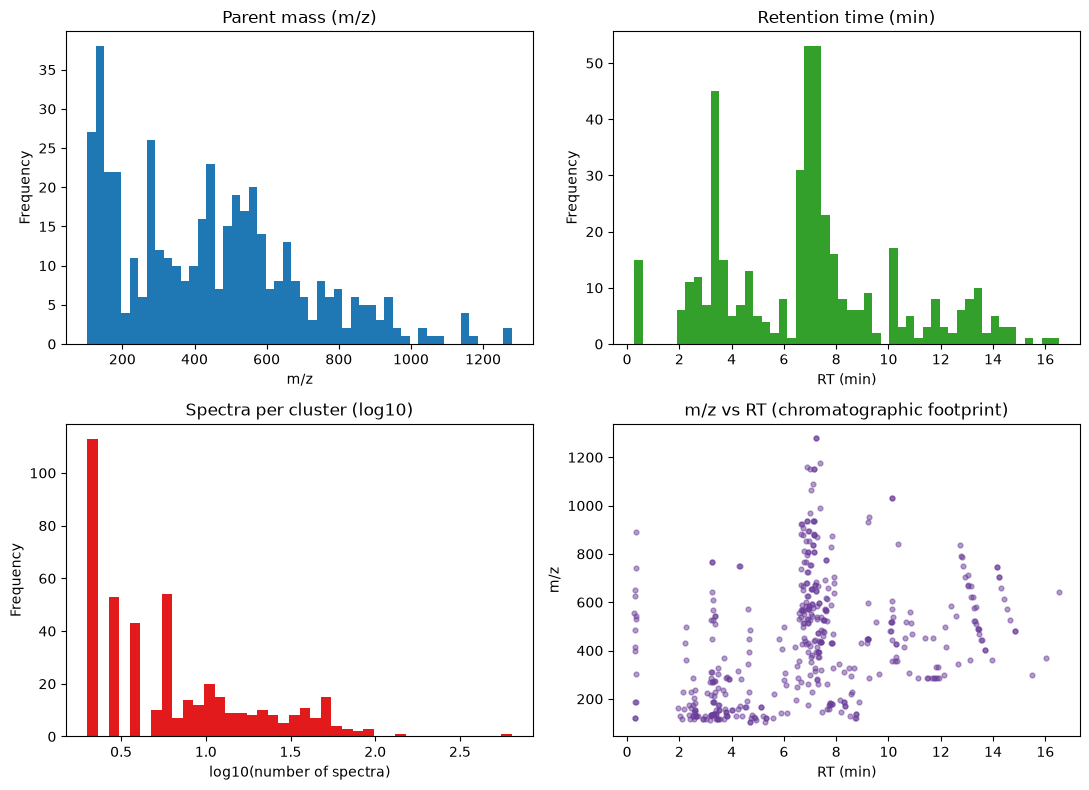

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

nodes["parent mass"].plot(kind="hist", bins=50, ax=axes[0,0], color="#1f78b4")
axes[0,0].set_title("Parent mass (m/z)")
axes[0,0].set_xlabel("m/z")

nodes["RTMean_min"].plot(kind="hist", bins=50, ax=axes[0,1], color="#33a02c")
axes[0,1].set_title("Retention time (min)")
axes[0,1].set_xlabel("RT (min)")

np.log10(nodes["number of spectra"]).plot(kind="hist", bins=40, ax=axes[1,0], color="#e31a1c")
axes[1,0].set_title("Spectra per cluster (log10)")
axes[1,0].set_xlabel("log10(number of spectra)")

axes[1,1].scatter(nodes["RTMean_min"], nodes["parent mass"], s=12, alpha=0.5, color="#6a3d9a")
axes[1,1].set_title("m/z vs RT (chromatographic footprint)")
axes[1,1].set_xlabel("RT (min)")
axes[1,1].set_ylabel("m/z")

plt.tight_layout()
plt.show()

- a pileup at RT < 1 min suggests unretained/void-volume?

In [7]:
print("Precursor charge distribution:")
print(nodes["precursor charge"].value_counts().sort_index())

early_rt = (nodes["RTMean_min"] < 1.0).sum()
print(f"\nFeatures eluting before 1 min (possible void-volume artifacts): {early_rt} ({100*early_rt/len(nodes):.1f}%)")

Precursor charge distribution:
precursor charge
1    445
Name: count, dtype: int64

Features eluting before 1 min (possible void-volume artifacts): 15 (3.4%)


## 4. Network structure — connectivity, cosine scores, mass differences

- Nodes are MS/MS clusters; edges link similar spectra (cosine ≥ threshold).
- Check degree distribution, component sizes, and cosine scores.
- Too few edges → threshold too strict or very diverse chemistry.
- Too many large components → threshold too permissive.

In [8]:
G = nx.Graph()
G.add_nodes_from(nodes["cluster index"])
for _, row in edges.iterrows():
    G.add_edge(row["CLUSTERID1"], row["CLUSTERID2"], cosine=row["Cosine"], delta_mz=row["DeltaMZ"])

components = list(nx.connected_components(G))
sizes = sorted((len(c) for c in components), reverse=True)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Connected components: {len(components)}")
print(f"Singletons: {sum(1 for s in sizes if s == 1)} ({100*sum(1 for s in sizes if s == 1)/len(sizes):.1f}% of components)")
print(f"Largest component: {sizes[0]} nodes")
print(f"Top 10 component sizes: {sizes[:10]}")

Nodes: 445, Edges: 279
Connected components: 256
Singletons: 199 (77.7% of components)
Largest component: 21 nodes
Top 10 component sizes: [21, 16, 15, 13, 11, 10, 9, 8, 7, 5]


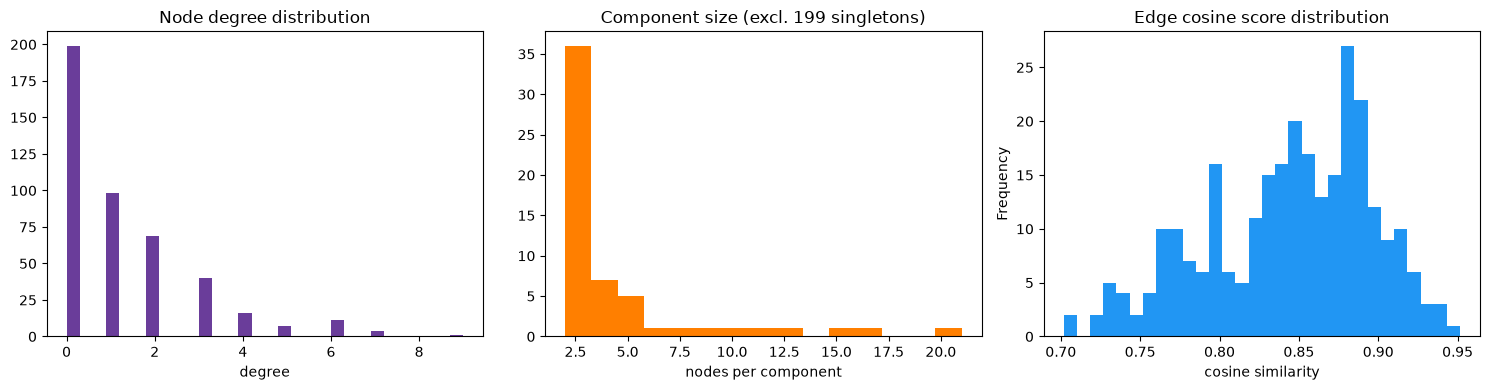

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

degrees = [d for _, d in G.degree()]
axes[0].hist(degrees, bins=30, color="#6a3d9a")
axes[0].set_title("Node degree distribution")
axes[0].set_xlabel("degree")

multi = [s for s in sizes if s > 1]
axes[1].hist(multi, bins=15, color="#ff7f00")
axes[1].set_title(f"Component size (excl. {sum(1 for s in sizes if s==1)} singletons)")
axes[1].set_xlabel("nodes per component")

edges["Cosine"].plot(kind="hist", bins=30, ax=axes[2], color="#2196F3")
axes[2].set_title("Edge cosine score distribution")
axes[2].set_xlabel("cosine similarity")

plt.tight_layout()
plt.show()

In [10]:
# DeltaMZ = mass difference between connected nodes. Recurring values often correspond to
# real biochemical transformations (methylation +14, hydroxylation +16, loss of water -18, etc).
top_deltas = edges["DeltaMZ"].round(1).value_counts().head(15)
top_deltas

DeltaMZ
-0.0      56
-44.0     32
-2.0      14
-18.0     12
-88.1     11
-1.0       9
-28.0      8
-132.1     7
-16.0      7
-52.1      7
-14.0      6
-176.1     5
-101.0     5
-34.0      4
-57.0      4
Name: count, dtype: int64

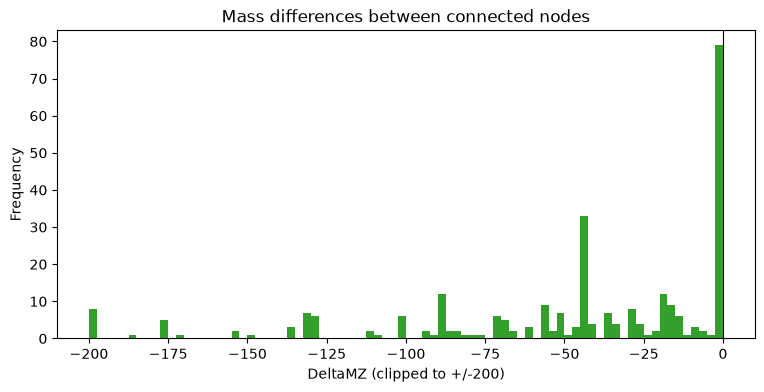

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
edges["DeltaMZ"].clip(-200, 200).plot(kind="hist", bins=80, ax=ax, color="#33a02c")
ax.set_xlabel("DeltaMZ (clipped to +/-200)")
ax.set_title("Mass differences between connected nodes")
ax.axvline(0, color="black", linewidth=0.8)
plt.show()

## 5. Library annotation coverage

- Measure fraction of isolate-derived nodes with valid library matches.
- Distinguish valid hits from artifacts (large mass error, ion-mobility libraries).
- Low annotation rates are common for environmental secondary metabolites.

Total nodes:        445
Valid library hits:  32 (7.2%)
Flagged hits:        31 (7.0%)
  - ion-mobility library source: 5
  - mass error > 300 ppm:      31
Unannotated:         382 (85.8%)


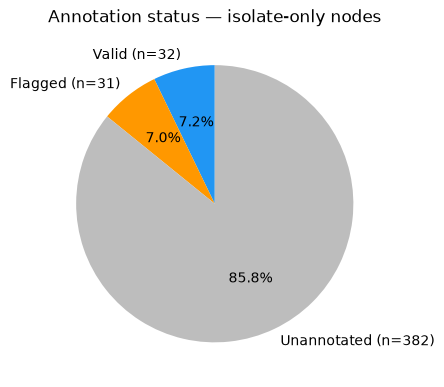

In [12]:
PPM_FLAG_LIMIT = 300

has_match = nodes["Compound_Name"].notna() & (nodes["Compound_Name"] != "")
flag_ion_mobility = has_match & nodes.get("LibraryName", pd.Series("", index=nodes.index)).str.contains("ION-MOBILITY", na=False)
flag_high_ppm = has_match & (nodes["MZErrorPPM"].abs() > PPM_FLAG_LIMIT)
artifact = flag_ion_mobility | flag_high_ppm
valid = has_match & ~artifact

print(f"Total nodes:        {len(nodes)}")
print(f"Valid library hits:  {valid.sum()} ({100*valid.mean():.1f}%)")
print(f"Flagged hits:        {artifact.sum()} ({100*artifact.mean():.1f}%)")
print(f"  - ion-mobility library source: {flag_ion_mobility.sum()}")
print(f"  - mass error > {PPM_FLAG_LIMIT} ppm:      {flag_high_ppm.sum()}")
print(f"Unannotated:         {(~has_match).sum()} ({100*(~has_match).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.pie([valid.sum(), artifact.sum(), (~has_match).sum()],
       labels=[f"Valid (n={valid.sum()})", f"Flagged (n={artifact.sum()})", f"Unannotated (n={(~has_match).sum()})"],
       colors=["#2196F3", "#FF9800", "#BDBDBD"], autopct="%1.1f%%", startangle=90)
ax.set_title("Annotation status — isolate-only nodes")
plt.show()

In [13]:
nodes.loc[valid, "MQScore"].describe().round(3)

count    32.000
mean      0.837
std       0.085
min       0.707
25%       0.768
50%       0.852
75%       0.893
max       0.992
Name: MQScore, dtype: float64

In [14]:
nodes.loc[valid, ["cluster index", "Compound_Name", "MQScore", "MZErrorPPM", "parent mass", "RTMean_min"]] \
    .sort_values("MQScore", ascending=False) \
    .head(32)

,cluster index,Compound_Name,MQScore,MZErrorPPM,parent mass,RTMean_min
82,148,Phenylalanine_(L-)_30EV,0.991867,4.593640,166.086095,5.138021
52,91,Adenine - 40.0 eV,0.987902,4.149400,136.061462,3.283547
81,145,Spectral Match to DL-Phenylalanine from NIST14,0.944979,0.459364,166.086084,5.115144
281,459,Spectral Match to 1-(9Z-Octadecenoyl)-sn-glyce...,0.937317,0.116846,522.354919,13.290000
188,320,Cetalkonium,0.930141,2.201830,360.362660,13.118249
176,301,Spectral Match to Benzyltetradecyldimethylammo...,0.926093,1.652920,332.331350,11.826272
128,233,cyclo(Phe-4-Hyp),0.923645,5.142280,261.122888,7.644781
122,219,Cyclo(-His-Pro),0.897255,4.153480,235.118214,2.609126
209,348,Trospium,0.890981,0.367495,415.210861,12.184971
88,156,Quinoline-4-carboxylic acid,0.887680,4.120320,174.054270,3.493492


## 6. Chemical class composition (NPClassifier)

- For valid library hits, report NPClassifier pathway counts.
- This shows broad chemical classes present in isolate-derived chemistry.

npclassifier_pathway
Terpenoids                                                  15
Alkaloids                                                    2
Amino acids and Peptides|Shikimates and Phenylpropanoids     2
Amino acids and Peptides                                     2
Alkaloids|Amino acids and Peptides                           1
Name: count, dtype: int64


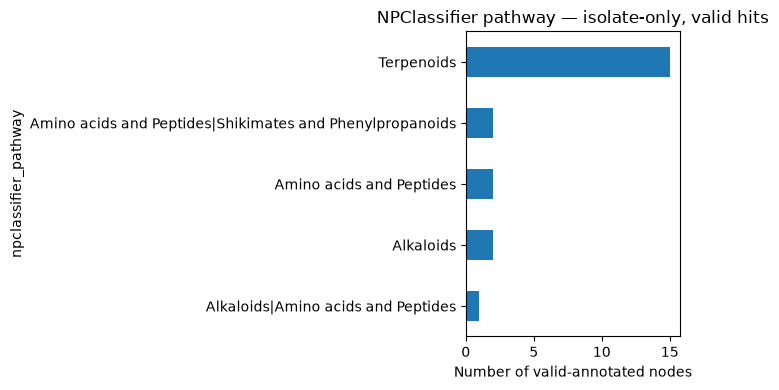

In [15]:
pathway_counts = nodes.loc[valid, "npclassifier_pathway"].dropna().value_counts()
print(pathway_counts)

if len(pathway_counts):
    fig, ax = plt.subplots(figsize=(7, 4))
    pathway_counts.sort_values().plot(kind="barh", ax=ax, color="#1f78b4")
    ax.set_xlabel("Number of valid-annotated nodes")
    ax.set_title("NPClassifier pathway — isolate-only, valid hits")
    plt.tight_layout()
    plt.show()

## 7. Isolate specificity — who's making what?

- How many nodes does each isolate contribute?
- How much chemistry is private to one isolate vs shared across isolates?
- Private nodes suggest strain-specific metabolites; shared nodes suggest conserved chemistry.

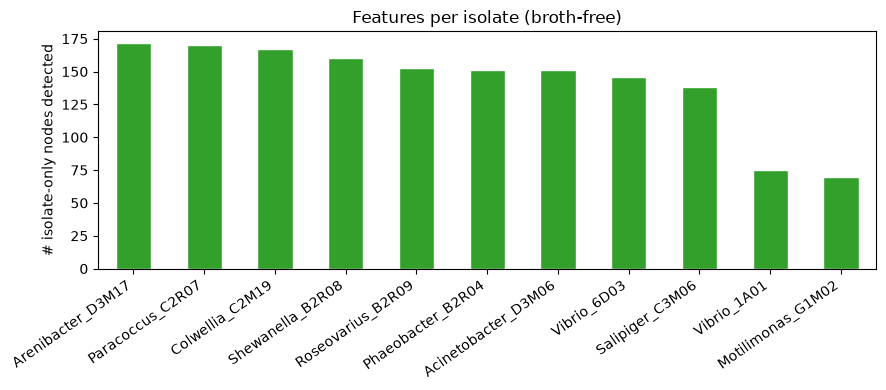

In [16]:
isolate_totals = (nodes[ISOLATE_COLS] > 0).sum().sort_values(ascending=False)
isolate_totals.index = [c.split(":")[-1] for c in isolate_totals.index]

fig, ax = plt.subplots(figsize=(9, 4))
isolate_totals.plot(kind="bar", ax=ax, color="#33a02c", edgecolor="white")
ax.set_ylabel("# isolate-only nodes detected")
ax.set_title("Features per isolate (broth-free)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [17]:
isolate_summary = pd.DataFrame({
    "total_nodes": (nodes[ISOLATE_COLS] > 0).sum(),
    "characterized_nodes": (nodes.loc[valid, ISOLATE_COLS] > 0).sum(),
})
isolate_summary.index = ISOLATE_LABELS
isolate_summary["pct_characterized"] = (100 * isolate_summary["characterized_nodes"] / isolate_summary["total_nodes"]).round(1)
isolate_summary = isolate_summary.sort_values("total_nodes", ascending=False)
isolate_summary

,total_nodes,characterized_nodes,pct_characterized
Arenibacter_D3M17,172,22,12.8
Paracoccus_C2R07,170,22,12.9
Colwellia_C2M19,167,19,11.4
Shewanella_B2R08,160,14,8.8
Roseovarius_B2R09,153,19,12.4
Phaeobacter_B2R04,151,19,12.6
Acinetobacter_D3M06,151,18,11.9
Vibrio_6D03,146,14,9.6
Salipiger_C3M06,138,20,14.5
Vibrio_1A01,75,3,4.0


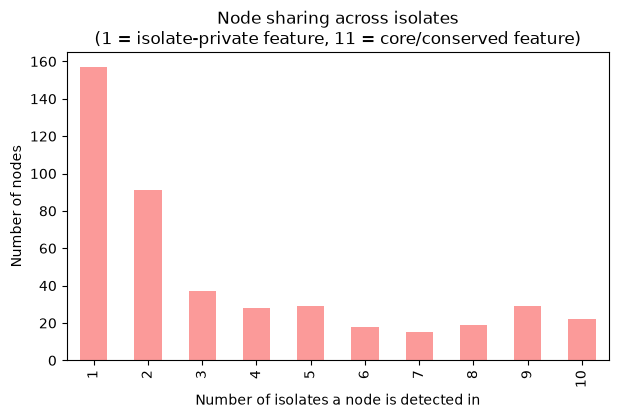

Isolate-private nodes (in exactly 1 isolate): 157 (35.3%)
Core nodes (in all 11 isolates):       0 (0.0%)


In [18]:
# n_isolates_detected_in: how many of the 11 isolates does each node appear in?
n_isolates_present = (nodes[ISOLATE_COLS] > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
n_isolates_present.value_counts().sort_index().plot(kind="bar", ax=ax, color="#fb9a99")
ax.set_xlabel("Number of isolates a node is detected in")
ax.set_ylabel("Number of nodes")
ax.set_title("Node sharing across isolates\n(1 = isolate-private feature, 11 = core/conserved feature)")
plt.show()

private = (n_isolates_present == 1).sum()
core = (n_isolates_present == len(ISOLATE_COLS)).sum()
print(f"Isolate-private nodes (in exactly 1 isolate): {private} ({100*private/len(nodes):.1f}%)")
print(f"Core nodes (in all {len(ISOLATE_COLS)} isolates):       {core} ({100*core/len(nodes):.1f}%)")

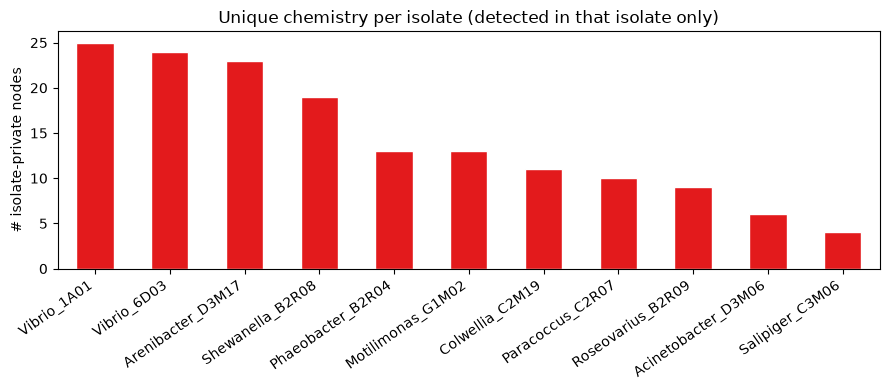

Vibrio_1A01            25
Vibrio_6D03            24
Arenibacter_D3M17      23
Shewanella_B2R08       19
Phaeobacter_B2R04      13
Motilimonas_G1M02      13
Colwellia_C2M19        11
Paracoccus_C2R07       10
Roseovarius_B2R09       9
Acinetobacter_D3M06     6
Salipiger_C3M06         4
Name: count, dtype: int64

In [19]:
# Which isolate contributes the most PRIVATE (unique) chemistry?
private_mask = n_isolates_present == 1
private_owner = nodes.loc[private_mask, ISOLATE_COLS].idxmax(axis=1).str.split(":").str[-1]
private_counts = private_owner.value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
private_counts.plot(kind="bar", ax=ax, color="#e31a1c", edgecolor="white")
ax.set_ylabel("# isolate-private nodes")
ax.set_title("Unique chemistry per isolate (detected in that isolate only)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

private_counts

## 8. annotated nodes mapped onto network position

- Map annotated nodes to component sizes.
- If annotated nodes sit in large families, they may have related unidentified analogs nearby.
- Singletons are less useful for analog-based dereplication.

Component size for valid-annotated nodes:
count    32.000000
mean      6.375000
std       6.338566
min       1.000000
25%       1.000000
50%       2.500000
75%      15.000000
max      15.000000
Name: cluster index, dtype: float64


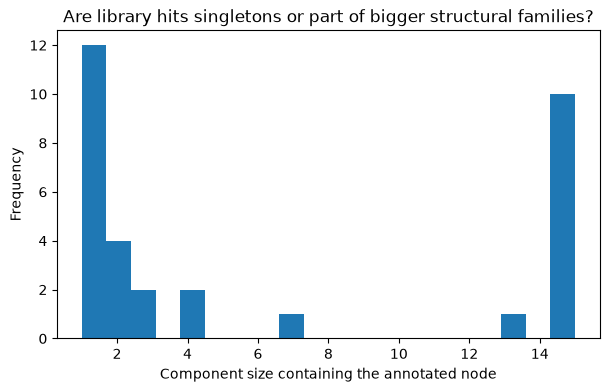

In [20]:
node_component_size = {n: len(c) for c in components for n in c}
annotated_component_sizes = nodes.loc[valid, "cluster index"].map(node_component_size)

print("Component size for valid-annotated nodes:")
print(annotated_component_sizes.describe())

fig, ax = plt.subplots(figsize=(7, 4))
annotated_component_sizes.plot(kind="hist", bins=20, ax=ax, color="#1f78b4")
ax.set_xlabel("Component size containing the annotated node")
ax.set_title("Are library hits singletons or part of bigger structural families?")
plt.show()

## Data summary

In [21]:
print("="*60)
print("ISOLATE-ONLY DATASET SUMMARY")
print("="*60)
print(f"Nodes: {len(nodes)}   Edges: {len(edges)}")
print(f"Connected components: {len(components)} (largest = {sizes[0]} nodes, {sum(1 for s in sizes if s==1)} singletons)")
print(f"Median cosine score: {edges['Cosine'].median():.3f}")
print(f"Library annotation: {valid.sum()} valid / {artifact.sum()} artifact / {(~has_match).sum()} unannotated")
print(f"Isolate-private nodes: {private} ({100*private/len(nodes):.1f}%)")
print(f"Core nodes (all isolates): {core} ({100*core/len(nodes):.1f}%)")
print(f"Top isolate by raw feature count: {isolate_totals.index[0]} ({isolate_totals.iloc[0]} features)")
print(f"Top isolate by private/unique chemistry: {private_counts.index[0]} ({private_counts.iloc[0]} private features)")

ISOLATE-ONLY DATASET SUMMARY
Nodes: 445   Edges: 279
Connected components: 256 (largest = 21 nodes, 199 singletons)
Median cosine score: 0.850
Library annotation: 32 valid / 31 artifact / 382 unannotated
Isolate-private nodes: 157 (35.3%)
Core nodes (all isolates): 0 (0.0%)
Top isolate by raw feature count: Arenibacter_D3M17 (172 features)
Top isolate by private/unique chemistry: Vibrio_1A01 (25 private features)
